# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 37: EXPANDED HYBRID PER-LABEL THRESHOLDS AND CAP
# ============================================================
# Purpose:
# This notebook refines the expanded hybrid candidate-150 model
# by testing per-label thresholds and optional prediction caps
# on top of the best expanded hybrid fusion from Notebook 36.
#
# The goal is to:
# 1. Load aligned structured and expanded-audio outputs
# 2. Recreate the best expanded hybrid from Notebook 36
# 3. Learn per-label thresholds on fused validation probabilities
# 4. Test simple label caps
# 5. Compare global-threshold hybrid vs per-label hybrid
# 6. Freeze both a benchmark mode and a conservative mode
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

SEED = 42
np.random.seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [2]:
# ============================================================
# 2. LOAD STRUCTURED AND EXPANDED AUDIO OUTPUTS
# ============================================================

structured_val_probs = np.load("../data/processed/structured_on_expanded_audio_candidate150_val_probs.npy")
structured_test_probs = np.load("../data/processed/structured_on_expanded_audio_candidate150_test_probs.npy")

audio_val_probs = np.load("../data/processed/audio_multilabel_candidate150_expanded_val_probs.npy")
audio_test_probs = np.load("../data/processed/audio_multilabel_candidate150_expanded_test_probs.npy")

Y_val_structured = np.load("../data/processed/structured_on_expanded_audio_candidate150_y_val.npy")
Y_test_structured = np.load("../data/processed/structured_on_expanded_audio_candidate150_y_test.npy")

Y_val_audio = np.load("../data/processed/audio_multilabel_candidate150_expanded_y_val.npy")
Y_test_audio = np.load("../data/processed/audio_multilabel_candidate150_expanded_y_test.npy")

structured_val_track_ids = np.load("../data/processed/structured_on_expanded_audio_candidate150_val_track_ids.npy")
structured_test_track_ids = np.load("../data/processed/structured_on_expanded_audio_candidate150_test_track_ids.npy")

audio_val_track_ids = np.load("../data/processed/audio_multilabel_candidate150_expanded_val_track_ids.npy")
audio_test_track_ids = np.load("../data/processed/audio_multilabel_candidate150_expanded_test_track_ids.npy")

structured_label_cols = np.load(
    "../data/processed/structured_on_expanded_audio_candidate150_label_columns.npy",
    allow_pickle=True
)

audio_label_cols = np.load(
    "../data/processed/audio_multilabel_candidate150_expanded_label_columns.npy",
    allow_pickle=True
)

print("Structured val probs shape:", structured_val_probs.shape)
print("Structured test probs shape:", structured_test_probs.shape)
print("Audio val probs shape:", audio_val_probs.shape)
print("Audio test probs shape:", audio_test_probs.shape)
print("Y_val_structured shape:", Y_val_structured.shape)
print("Y_test_structured shape:", Y_test_structured.shape)
print("Y_val_audio shape:", Y_val_audio.shape)
print("Y_test_audio shape:", Y_test_audio.shape)

Structured val probs shape: (1500, 150)
Structured test probs shape: (1500, 150)
Audio val probs shape: (1500, 150)
Audio test probs shape: (1500, 150)
Y_val_structured shape: (1500, 150)
Y_test_structured shape: (1500, 150)
Y_val_audio shape: (1500, 150)
Y_test_audio shape: (1500, 150)


In [3]:
# ============================================================
# 3. VERIFY ALIGNMENT
# ============================================================

print("Label columns match:", np.array_equal(structured_label_cols, audio_label_cols))
print("Validation track IDs match:", np.array_equal(structured_val_track_ids, audio_val_track_ids))
print("Test track IDs match:", np.array_equal(structured_test_track_ids, audio_test_track_ids))
print("Validation targets match:", np.array_equal(Y_val_structured, Y_val_audio))
print("Test targets match:", np.array_equal(Y_test_structured, Y_test_audio))

assert np.array_equal(structured_label_cols, audio_label_cols), "Label columns do not match."
assert np.array_equal(structured_val_track_ids, audio_val_track_ids), "Validation track IDs do not match."
assert np.array_equal(structured_test_track_ids, audio_test_track_ids), "Test track IDs do not match."
assert np.array_equal(Y_val_structured, Y_val_audio), "Validation targets do not match."
assert np.array_equal(Y_test_structured, Y_test_audio), "Test targets do not match."

label_cols = structured_label_cols.copy()
Y_val = Y_val_structured.copy()
Y_test = Y_test_structured.copy()

print("Number of labels:", len(label_cols))

Label columns match: True
Validation track IDs match: True
Test track IDs match: True
Validation targets match: True
Test targets match: True
Number of labels: 150


In [4]:
# ============================================================
# 4. LOAD BEST EXPANDED HYBRID CONFIG FROM NOTEBOOK 36
# ============================================================

best_config = {}
with open("../data/processed/hybrid_multilabel_candidate150_expanded_best_config.txt", "r") as f:
    for line in f:
        line = line.strip()
        if "=" in line:
            k, v = line.split("=")
            best_config[k.strip()] = float(v.strip())

best_w_structured = best_config["structured_weight"]
best_w_audio = best_config["audio_weight"]
best_global_threshold = best_config["threshold"]

print("Best expanded hybrid config from Notebook 36:")
print("Structured weight:", best_w_structured)
print("Audio weight:", best_w_audio)
print("Global threshold:", best_global_threshold)

Best expanded hybrid config from Notebook 36:
Structured weight: 0.1
Audio weight: 0.9
Global threshold: 0.2


In [5]:
# ============================================================
# 5. DEFINE HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Avg Predicted Labels": float(y_pred.sum(axis=1).mean())
    }

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

def fuse_probabilities(structured_probs, audio_probs, w_structured=0.5, w_audio=0.5):
    return (w_structured * structured_probs) + (w_audio * audio_probs)

def decode_global_threshold(prob_matrix, threshold, ensure_at_least_one=False):
    y_pred = (prob_matrix >= threshold).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]
        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

def decode_per_label_threshold(prob_matrix, thresholds, ensure_at_least_one=False):
    y_pred = np.zeros_like(prob_matrix, dtype=np.uint8)

    for j in range(prob_matrix.shape[1]):
        y_pred[:, j] = (prob_matrix[:, j] >= thresholds[j]).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]
        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

def apply_label_cap(prob_matrix, y_pred, max_labels=None, ensure_at_least_one=False):
    y_final = y_pred.copy()

    if max_labels is not None:
        for i in range(y_final.shape[0]):
            pos_idx = np.where(y_final[i] == 1)[0]
            if len(pos_idx) > max_labels:
                pos_scores = prob_matrix[i, pos_idx]
                keep_order = np.argsort(-pos_scores)[:max_labels]
                keep_idx = pos_idx[keep_order]
                y_final[i, :] = 0
                y_final[i, keep_idx] = 1

    if ensure_at_least_one:
        row_sums = y_final.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]
        if len(zero_rows) > 0:
            top_idx = np.argmax(prob_matrix[zero_rows], axis=1)
            y_final[zero_rows, top_idx] = 1

    return y_final

In [6]:
# ============================================================
# 6. RECREATE THE BEST EXPANDED HYBRID FUSED PROBABILITIES
# ============================================================

fused_val_probs = fuse_probabilities(
    structured_val_probs,
    audio_val_probs,
    w_structured=best_w_structured,
    w_audio=best_w_audio
)

fused_test_probs = fuse_probabilities(
    structured_test_probs,
    audio_test_probs,
    w_structured=best_w_structured,
    w_audio=best_w_audio
)

print("Fused validation probability shape:", fused_val_probs.shape)
print("Fused test probability shape:", fused_test_probs.shape)

Fused validation probability shape: (1500, 150)
Fused test probability shape: (1500, 150)


In [7]:
# ============================================================
# 7. RECREATE GLOBAL-THRESHOLD HYBRID RESULTS
# ============================================================

Y_val_pred_global = decode_global_threshold(
    fused_val_probs,
    best_global_threshold,
    ensure_at_least_one=False
)

Y_test_pred_global = decode_global_threshold(
    fused_test_probs,
    best_global_threshold,
    ensure_at_least_one=False
)

global_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_global,
    name="Expanded Hybrid Global Threshold"
)

global_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_global,
    name="Expanded Hybrid Global Threshold"
)

p3_val_global, r3_val_global = precision_recall_at_k(Y_val, fused_val_probs, k=3)
p5_val_global, r5_val_global = precision_recall_at_k(Y_val, fused_val_probs, k=5)

global_val_results["Precision@3"] = p3_val_global
global_val_results["Recall@3"] = r3_val_global
global_val_results["Precision@5"] = p5_val_global
global_val_results["Recall@5"] = r5_val_global

p3_test_global, r3_test_global = precision_recall_at_k(Y_test, fused_test_probs, k=3)
p5_test_global, r5_test_global = precision_recall_at_k(Y_test, fused_test_probs, k=5)

global_test_results["Precision@3"] = p3_test_global
global_test_results["Recall@3"] = r3_test_global
global_test_results["Precision@5"] = p5_test_global
global_test_results["Recall@5"] = r5_test_global

print("Recreated expanded hybrid validation results:")
print(global_val_results)

print("\nRecreated expanded hybrid test results:")
print(global_test_results)

Recreated expanded hybrid validation results:
{'Model': 'Expanded Hybrid Global Threshold', 'Micro F1': 0.39502113668388916, 'Macro F1': 0.048471339668921164, 'Samples F1': 0.39403662448662446, 'Micro Precision': 0.3650701779771379, 'Micro Recall': 0.4303257717891864, 'Hamming Loss': 0.034346666666666664, 'Subset Accuracy': 0.0013333333333333333, 'Avg Predicted Labels': 4.607333333333333, 'Precision@3': 0.4537777777777778, 'Recall@3': 0.3897049206349207, 'Precision@5': 0.348, 'Recall@5': 0.49362359788359783}

Recreated expanded hybrid test results:
{'Model': 'Expanded Hybrid Global Threshold', 'Micro F1': 0.3910226015489173, 'Macro F1': 0.05641025973453137, 'Samples F1': 0.3867405365875954, 'Micro Precision': 0.3493856799887022, 'Micro Recall': 0.4439260721335008, 'Hamming Loss': 0.03424888888888889, 'Subset Accuracy': 0.0013333333333333333, 'Avg Predicted Labels': 4.720666666666666, 'Precision@3': 0.42977777777777776, 'Recall@3': 0.38276625781625784, 'Precision@5': 0.33533333333333337

In [8]:
# ============================================================
# 8. LEARN PER-LABEL THRESHOLDS ON FUSED VALIDATION PROBABILITIES
# ============================================================

threshold_grid = np.arange(0.05, 0.55, 0.05)
best_thresholds_per_label = np.zeros(fused_val_probs.shape[1], dtype=np.float32)

for j in range(fused_val_probs.shape[1]):
    y_true_j = Y_val[:, j]
    probs_j = fused_val_probs[:, j]

    best_f1_j = -1.0
    best_t_j = threshold_grid[0]

    for t in threshold_grid:
        y_pred_j = (probs_j >= t).astype(np.uint8)
        f1_j = f1_score(y_true_j, y_pred_j, zero_division=0)

        if f1_j > best_f1_j:
            best_f1_j = f1_j
            best_t_j = t

    best_thresholds_per_label[j] = best_t_j

print("Per-label thresholds learned for expanded fused probabilities.")
print("Unique thresholds chosen:", np.unique(best_thresholds_per_label))

Per-label thresholds learned for expanded fused probabilities.
Unique thresholds chosen: [0.05 0.1  0.15 0.2  0.25 0.3  0.4 ]


In [9]:
# ============================================================
# 9. EVALUATE HYBRID WITH PER-LABEL THRESHOLDS
# ============================================================

Y_val_pred_per_label = decode_per_label_threshold(
    fused_val_probs,
    best_thresholds_per_label,
    ensure_at_least_one=False
)

Y_test_pred_per_label = decode_per_label_threshold(
    fused_test_probs,
    best_thresholds_per_label,
    ensure_at_least_one=False
)

per_label_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_per_label,
    name="Expanded Hybrid Per-Label Thresholds"
)

per_label_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_per_label,
    name="Expanded Hybrid Per-Label Thresholds"
)

per_label_val_results["Precision@3"] = p3_val_global
per_label_val_results["Recall@3"] = r3_val_global
per_label_val_results["Precision@5"] = p5_val_global
per_label_val_results["Recall@5"] = r5_val_global

per_label_test_results["Precision@3"] = p3_test_global
per_label_test_results["Recall@3"] = r3_test_global
per_label_test_results["Precision@5"] = p5_test_global
per_label_test_results["Recall@5"] = r5_test_global

print("Expanded hybrid per-label validation results:")
print(per_label_val_results)

print("\nExpanded hybrid per-label test results:")
print(per_label_test_results)

Expanded hybrid per-label validation results:
{'Model': 'Expanded Hybrid Per-Label Thresholds', 'Micro F1': 0.20043887147335424, 'Macro F1': 0.09758701634319086, 'Samples F1': 0.20391456833375998, 'Micro Precision': 0.12278680339516841, 'Micro Recall': 0.5452839843083745, 'Hamming Loss': 0.11336, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 17.358, 'Precision@3': 0.4537777777777778, 'Recall@3': 0.3897049206349207, 'Precision@5': 0.348, 'Recall@5': 0.49362359788359783}

Expanded hybrid per-label test results:
{'Model': 'Expanded Hybrid Per-Label Thresholds', 'Micro F1': 0.19144207593827275, 'Macro F1': 0.09366385331678821, 'Samples F1': 0.19488577652837974, 'Micro Precision': 0.11594752407674225, 'Micro Recall': 0.5487170285304145, 'Hamming Loss': 0.11480444444444445, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 17.582666666666668, 'Precision@3': 0.42977777777777776, 'Recall@3': 0.38276625781625784, 'Precision@5': 0.33533333333333337, 'Recall@5': 0.48783220298220303}


In [10]:
# ============================================================
# 10. LABEL-CAP SEARCH ON VALIDATION
# ============================================================

cap_results = []

for cap in [None, 8, 6, 5, 4, 3]:
    Y_val_pred_cap = apply_label_cap(
        fused_val_probs,
        Y_val_pred_per_label,
        max_labels=cap,
        ensure_at_least_one=False
    )

    cap_name = (
        "Expanded Hybrid Per-Label Thresholds"
        if cap is None else f"Expanded Hybrid Per-Label + Cap-{cap}"
    )

    results = evaluate_multilabel(
        Y_val,
        Y_val_pred_cap,
        name=cap_name
    )

    results["Cap"] = "None" if cap is None else cap
    cap_results.append(results)

cap_results_df = pd.DataFrame(cap_results).sort_values(
    ["Micro F1", "Macro F1", "Samples F1"],
    ascending=False
).reset_index(drop=True)

print("Expanded hybrid validation label-cap search:")
display(cap_results_df)

Expanded hybrid validation label-cap search:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Cap
0,Expanded Hybrid Per-Label + Cap-3,0.380778,0.041602,0.382437,0.438444,0.336517,0.028520,0.003333,3.000000,3
1,Expanded Hybrid Per-Label + Cap-4,0.376296,0.056703,0.374879,0.372000,0.380692,0.032884,0.000667,4.000000,4
2,Expanded Hybrid Per-Label + Cap-5,0.367582,0.070593,0.364567,0.327467,0.418898,0.037560,0.000667,5.000000,5
3,Expanded Hybrid Per-Label + Cap-6,0.355245,0.084353,0.350712,0.293333,0.450281,0.042591,0.000000,6.000000,6
4,Expanded Hybrid Per-Label + Cap-8,0.319780,0.093820,0.314665,0.238056,0.486952,0.053982,0.000000,7.995333,8
5,Expanded Hybrid Per-Label Thresholds,0.200439,0.097587,0.203915,0.122787,0.545284,0.113360,0.000000,17.358000,None


In [11]:
# ============================================================
# 11. SELECT BEST FINAL EXPANDED HYBRID DECODING RULE
# ============================================================

best_cap_row = cap_results_df.iloc[0].to_dict()
best_cap_value = best_cap_row["Cap"]

print("Best final expanded hybrid decoding rule:")
print(best_cap_row)

Best final expanded hybrid decoding rule:
{'Model': 'Expanded Hybrid Per-Label + Cap-3', 'Micro F1': 0.38077776705587185, 'Macro F1': 0.04160202551528998, 'Samples F1': 0.3824372331372331, 'Micro Precision': 0.43844444444444447, 'Micro Recall': 0.3365171413951902, 'Hamming Loss': 0.02852, 'Subset Accuracy': 0.0033333333333333335, 'Avg Predicted Labels': 3.0, 'Cap': 3}


In [12]:
# ============================================================
# 12. APPLY BEST FINAL DECODING RULE TO TEST
# ============================================================

if best_cap_value == "None":
    Y_test_pred_final = Y_test_pred_per_label.copy()
    final_test_results = per_label_test_results.copy()
else:
    Y_test_pred_final = apply_label_cap(
        fused_test_probs,
        Y_test_pred_per_label,
        max_labels=int(best_cap_value),
        ensure_at_least_one=False
    )

    final_test_results = evaluate_multilabel(
        Y_test,
        Y_test_pred_final,
        name="Expanded Hybrid Per-Label + Best Cap"
    )

    final_test_results["Precision@3"] = p3_test_global
    final_test_results["Recall@3"] = r3_test_global
    final_test_results["Precision@5"] = p5_test_global
    final_test_results["Recall@5"] = r5_test_global

print("Final expanded hybrid test results:")
print(final_test_results)

Final expanded hybrid test results:
{'Model': 'Expanded Hybrid Per-Label + Best Cap', 'Micro F1': 0.37585624937952944, 'Macro F1': 0.045106380732963275, 'Samples F1': 0.3768316942316942, 'Micro Precision': 0.4206666666666667, 'Micro Recall': 0.3396734254441055, 'Hamming Loss': 0.027942222222222222, 'Subset Accuracy': 0.005333333333333333, 'Avg Predicted Labels': 3.0, 'Precision@3': 0.42977777777777776, 'Recall@3': 0.38276625781625784, 'Precision@5': 0.33533333333333337, 'Recall@5': 0.48783220298220303}


In [13]:
# ============================================================
# 13. BUILD GLOBAL VS PER-LABEL VS FINAL TEST COMPARISON
# ============================================================

comparison_df = pd.DataFrame([
    global_test_results,
    per_label_test_results,
    final_test_results
]).drop_duplicates(subset=["Model"]).reset_index(drop=True)

print("Expanded hybrid test comparison:")
display(comparison_df)

Expanded hybrid test comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Expanded Hybrid Global Threshold,0.391023,0.056410,0.386741,0.349386,0.443926,0.034249,0.001333,4.720667,0.429778,0.382766,0.335333,0.487832
1,Expanded Hybrid Per-Label Thresholds,0.191442,0.093664,0.194886,0.115948,0.548717,0.114804,0.000000,17.582667,0.429778,0.382766,0.335333,0.487832
2,Expanded Hybrid Per-Label + Best Cap,0.375856,0.045106,0.376832,0.420667,0.339673,0.027942,0.005333,3.000000,0.429778,0.382766,0.335333,0.487832


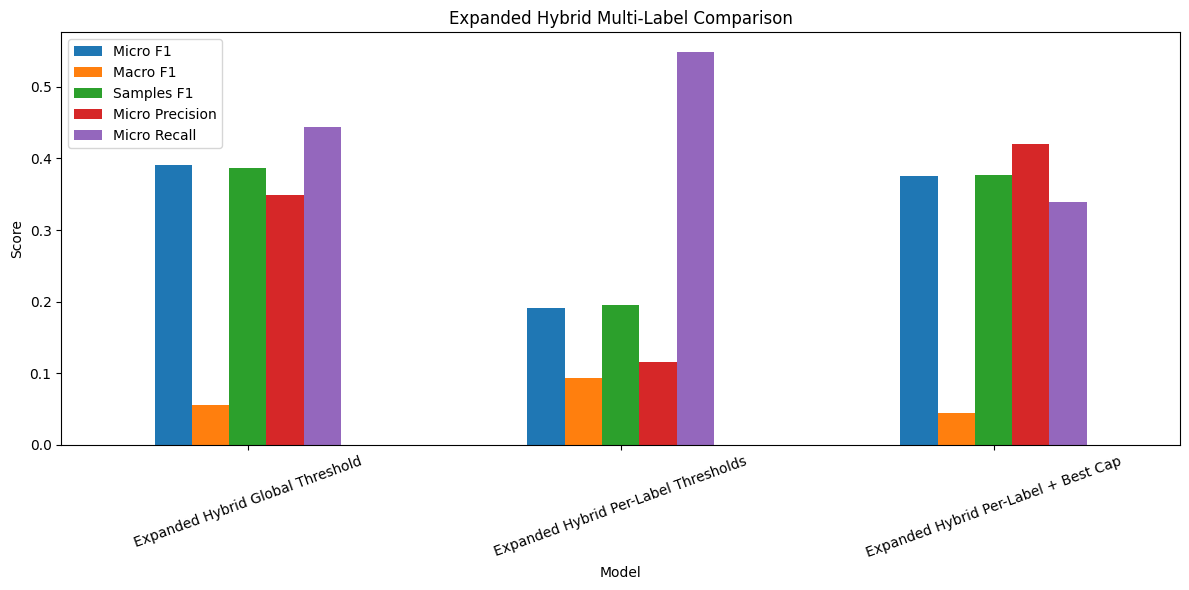

In [14]:
# ============================================================
# 14. PLOT MAIN COMPARISON
# ============================================================

plot_cols = ["Micro F1", "Macro F1", "Samples F1", "Micro Precision", "Micro Recall"]

plot_df = comparison_df.set_index("Model")[plot_cols]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Expanded Hybrid Multi-Label Comparison")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 15. SAVE OUTPUTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

cap_results_df.to_csv(
    "../data/processed/hybrid_multilabel_candidate150_expanded_per_label_cap_search.csv",
    index=False
)

comparison_df.to_csv(
    "../data/processed/hybrid_multilabel_candidate150_expanded_per_label_comparison.csv",
    index=False
)

pd.DataFrame([final_test_results]).to_csv(
    "../data/processed/hybrid_multilabel_candidate150_expanded_per_label_final_test_results.csv",
    index=False
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_expanded_best_per_label_thresholds.npy",
    best_thresholds_per_label
)

np.save(
    "../data/processed/hybrid_multilabel_candidate150_expanded_per_label_test_pred.npy",
    Y_test_pred_final
)

with open("../data/processed/hybrid_multilabel_candidate150_expanded_best_per_label_cap.txt", "w") as f:
    f.write(str(best_cap_value))

print("Saved expanded hybrid per-label threshold outputs.")

Saved expanded hybrid per-label threshold outputs.


In [16]:
# ============================================================
# 16. INTERPRETATION NOTES
# ============================================================

print("1. This notebook refines the expanded hybrid model by testing per-label thresholds and simple caps.")
print("2. Per-label thresholds are learned directly from fused validation probabilities.")
print("3. The label-cap search is included to see whether a conservative prediction mode is cleaner than the benchmark mode.")
print("4. The final comparison shows whether the expanded benchmark hybrid still wins on Micro F1.")
print("5. The output can support both a benchmark result and a deployment-style conservative result.")

1. This notebook refines the expanded hybrid model by testing per-label thresholds and simple caps.
2. Per-label thresholds are learned directly from fused validation probabilities.
3. The label-cap search is included to see whether a conservative prediction mode is cleaner than the benchmark mode.
4. The final comparison shows whether the expanded benchmark hybrid still wins on Micro F1.
5. The output can support both a benchmark result and a deployment-style conservative result.
